### **A2.1 Regresión logística y validación cruzada**

Se planea hacer un análisis socioeconómico de los determinantes de supervivencia ante una catástrofe marítima.


Para esto, se toma el ejemplo del Titanic, el cuál colisionó con un iceberg el 14 de abril de 1912, con sólo 712 sobrevivientes de las 2225 personas que iban a bordo, de los cuales la mayoría de ellos eran de primera clase (Wikipedia, s.f).


Se utiliza la base de datos de *Kaggle* llamada **[Titanic Dataset](https://www.kaggle.com/datasets/yasserh/titanic-dataset)**




La base de datos contiene las siguientes columnas:


* PassengerId: Número del 1 al 891 con el número de identificación del pasajero. Esta variable, no será considerada para este proyecto, debido a que no aporta información que pueda predecir la supervivencia de un pasajero y su relación con su estatus económico.
* Survived: Esta columna indica si sobrevivió el pasajero o no. 1 = No, 1 = Sí.
* Pclass: Tipo de clase dentro del barco. 1 = primera clase, 2 = segunda clase, 3 = tercera clase.
* Name: Nombre del pasajero. Esta variable tampoco será integrada al modelo por las mismas razones.
* Sex: Sexo del pasajero. 'male' o 'female'.
* Edad: Valor numérico con la edad del pasajero.
* SibSp: Número de hermanos o parejas del pasajero a bordo.
* Parch: Número de padres o hijos del pasajero a bordo.
* Ticket: Número de ticket. Esta variable tampoco se utilizará para el modelo.
* Fare: Tarifa pagada por el pasajero.
* Cabin: Número de cabina. También se excluirá del modelo.
* Embarked: Puerto de embarcación. C = Cherbourg, Q = Queenstown o S = Southampton.
---




En el bloque de código siguiente se cargan las bases de datos anteriormente mencionadas al espacio de trabajo. Esto se logra primero descargando la librería de terceros `kagglehub` usando la función `pip intall`, luego importando la librería "pandas", `os` (la cual permite interactuar con el sistema operativo) y `glob` (que sirve para buscar el archivo que coincida el patrón específico).

  Posteriormente se descarga la versión más reciente de la base de datos, usando la dirección del repositorio obtenido directamente de la página web. Para esto se usa la función `dataset_download()`. Se imprime la ruta para verificar dónde se guardó la base de datos, usando `print`. Después, se busca el archivo con extensión "*.csv*". Luego se carga la base de datos, usando un `if`, donde se condiciona a que si se encuentra al menos un archivo "*.csv*", se tome el primero de la lista y se guarda en la variable `df_all_columns`, que contiene todas las variables, usando la función `read_csv()`. Se imprimen las primeras 10 filas con `head(10)`, para asegurar que se hayan realizado estos datos de manera correcta.


  Debido a que no se van a incluir ciertas columnas debido a que no aportaran al modelo, se crea una variable `columns to exclude`, añadiendo los nombres de las columnas que no se van a añadir. Después se crea una variable, de una nueva base de datos que no incluya las columnas anteriormente mencionadas, usando la variable `drop()`, dándole como parámetros las columnas a excluir y `error='ignore'` que servirá para que no marque error en caso de que no exista alguna columna. Por último se imprimen las primeras 10 columnas para confirmar que se haya creado esta nueva base de datos correctamente.


  En caso de que no se encuentre ningún archivo, se imprimirá un error en la pantalla.





In [1]:
pip install kagglehub

In [2]:
import kagglehub
import pandas as pd
import os
import glob

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)

# Find the CSV file within the downloaded directory
csv_files = glob.glob(os.path.join(path, '*.csv'))

if csv_files:
    csv_file_path = csv_files[0]
    print(f"Found CSV file: {csv_file_path}")
    # Load the dataset into a pandas DataFrame
    df_all_columns = pd.read_csv(csv_file_path)
    print("\nFirst 10 rows of the full dataset:")
    display(df_all_columns.head(10))

    # Create a second variable excluding specified columns
    columns_to_exclude = ["PassengerId", "Name", "Ticket", "Cabin"]
    df_model = df_all_columns.drop(columns=columns_to_exclude, errors='ignore')
    print("\nFirst 10 rows of the dataset for the model (excluding PassengerId, Name, Ticket, Cabin):")
    display(df_model.head(10))
    print("\nRows:", df_model.shape[0])
else:
    print("No CSV file found in the downloaded dataset directory.")

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset
Found CSV file: /kaggle/input/titanic-dataset/Titanic-Dataset.csv

First 10 rows of the full dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C



First 10 rows of the dataset for the model (excluding PassengerId, Name, Ticket, Cabin):


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
5,0,3,male,NaN,0,0,8.4583,Q
6,0,1,male,54.0,0,0,51.8625,S
7,0,3,male,2.0,3,1,21.0750,S
8,1,3,female,27.0,0,2,11.1333,S
9,1,2,female,14.0,1,0,30.0708,C



Rows: 891


La base de datos cuenta con 891 datos.


Como se puede observar, la variable `Sex` es una variable categórica, lo cuál representaría un problema si se mantiene así a la hora de crear el modelo. Existe este mismo problema para la variable `Embarked` donde se tienen 3 clases distintas. Además, puede haber la posibilidad de que existan outliers o valores faltantes, por lo que se deberá tomar acción para corregir lo anteriormente comentado.


Antes de esto, para que no haya fuga de datos en este proceso, se separarán los valores de la base de datos en `train` (80%) y `test` (20%), primero añadiendo a la variable `X` los valores de `Survived`, y a `y` añadiendo todo lo demás. Se separan los valores importando la librería `train_test_split`, para después usar una función con este mismo nombre, poniendo como parámetros ambas variables a dividir (`X` y `y`), el tamaño del conjunto de prueba, agregando una semilla de aleatoriedad, y estratificando las variable analizar, para que haya proporción de cada clase en los datos y no se exponga a overfitting, al sólo incluir una sóla clase.


Se imprimen los tamaños de estas nuevas variables para saber cuántos datos quedaron en cada una de ellas, usando la función `.shape`. Después se imprimen las primeras 5 filas de los datos de entrenamiento.











In [3]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_model.drop('Survived', axis=1)
y = df_model['Survived']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nFirst 5 rows of X_train:")
display(X_train.head())
print("\nFirst 5 rows of y_train:")
display(y_train.head())

print("\nDistribution of Survived in original data:")
print(y.value_counts(normalize=True))

print("\nDistribution of Survived in y_train:")
print(y_train.value_counts(normalize=True))

print("\nDistribution of Survived in y_test:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (712, 7)
Shape of X_test: (179, 7)
Shape of y_train: (712,)
Shape of y_test: (179,)

First 5 rows of X_train:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
692,3,male,NaN,0,0,56.4958,S
481,2,male,NaN,0,0,0.0000,S
527,1,male,NaN,0,0,221.7792,S
855,3,female,18.0,0,1,9.3500,S
801,2,female,31.0,1,1,26.2500,S



First 5 rows of y_train:


,Survived
692,1
481,0
527,0
855,1
801,1



Distribution of Survived in original data:
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Distribution of Survived in y_train:
Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Distribution of Survived in y_test:
Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


Ahora sí, una vez separada la base de datos, se ejecutó un código para encontrar posibles outliers. Se usa el método de Rango Intercuartil (IQR method). Para lograr esto, se crea un `for` loop, para recorrer cada columna en búsqueda de posibles outliers. Después se encuentra el `Q1` y `Q3` de cada columna, usando la función `quantile()` y agregando como parámetro el cuartil que se busca. Esto se hace para los valores de `X_train`. Posteriormente se calcula el Rango Intercuartil (`IQR`) restando `Q3` y `Q1`. Se establecen los límites, menor y mayor, para poder detectar los valores atípicos, restándole 1.5*IQR a Q1, y sumándoles esta misma cantidad a Q3.


Luego se clasifican los outliers que estén fuera de estos límites. Si hay outliers, se imprimen de manera ordenada, con la función `.sort_values()`, de lo contrario, se imprime un mensaje indicando que no se encontraron outliers para esa columna. Esto se hace con la finalidad de poder analizarlos después, de manera individual.





In [4]:
print("\nIndividual Outliers for Numerical Columns in X_train:")

# Redefine numerical_cols as it was not defined in the current kernel state
numerical_cols = X_train.select_dtypes(include=['number']).columns

for col in numerical_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = X_train[(X_train[col] < lower_bound) | (X_train[col] > upper_bound)][col]

    if not outliers.empty:
        print(f"\nOutliers for column '{col}':")
        display(outliers.sort_values())
    else:
        print(f"\nNo significant outliers found for column '{col}' based on IQR method.")


Individual Outliers for Numerical Columns in X_train:

No significant outliers found for column 'Pclass' based on IQR method.

Outliers for column 'Age':


,Age
672,70.0
116,70.5
493,71.0
96,71.0
851,74.0
630,80.0



Outliers for column 'SibSp':


,SibSp
409,3
63,3
819,3
176,3
7,3
374,3
24,3
85,3
642,3
229,3



Outliers for column 'Parch':


,Parch
855,1
801,1
409,1
197,1
323,1
...,...
638,5
25,5
885,5
13,5



Outliers for column 'Fare':


,Fare
151,66.6000
641,69.3000
792,69.5500
846,69.5500
201,69.5500
...,...
742,262.3750
311,262.3750
438,263.0000
737,512.3292


**Pclass**
Para esta variable no se encontraron posibles outliers. Aunque a primera vista pareciera una variable numérica, realmente es una variable categórica, ya que se trata del tipo de clase en la que viajaba el pasajero, sólo habiendo 3 posibles opciones.


**Age**
Para esta variable se detectaron 6 posibles outliers. Sin embargo, no parecen serlo; están dentro de edades razonables. Es posible que la mayoría de las personas que estaban en este barco eran personas más jóvenes, debido a que buscaban nuevas oportunidades o tenían mayores ingresos para permitirse un viaje así. Todos los datos se mantendrán.


**SibSp**
Para esta variable se encontraron más posibles outliers. Aunque sería muy poco posible que algún pasajero tuviera más de una pareja en el mismo barco, sí es posible que tuvieran 8 hermanos dentro del barco. Antes, las familias solían ser muy numerosas. Por esta misma razón, se van a mantener todos estos valores. Además que sería interesante ver si esta variable afecta significativamente las posibilidades de sobrevivir, *e.g.* se puede priorizar el bienestar de los seres queridos antes que el propio.


**Parch**
De igual manera, no sería común tener más de 2 padres a bordo del mismo barco, sin embargo, como la variable también incluye la cantidad de hijos del pasajero a bordo, sí es posible que la persona viniera con 6 hijos. Por la misma razón que la variable anterior, se mantendrán todos estos valores.


**Fare**
Para esta variable, sí se encontraron múltiples posibles outliers (91 en total). Para este caso los datos sí varían mucho entre sí, teniendo valores como 66.60 y costos de hasta 512.33. Haciendo un poco de investigación, se encontró la **Imagen 1.**, que ejemplifica los costos de los boletos para cada clase. Tomando esto como referencia, se puede decir que los valores encontrados como posibles outliers no son errores; menos personas pagaron boletos de segunda y tercera clase.  
**Imagen 1. Tabla Costos Titanic (Fielding, 2025)**
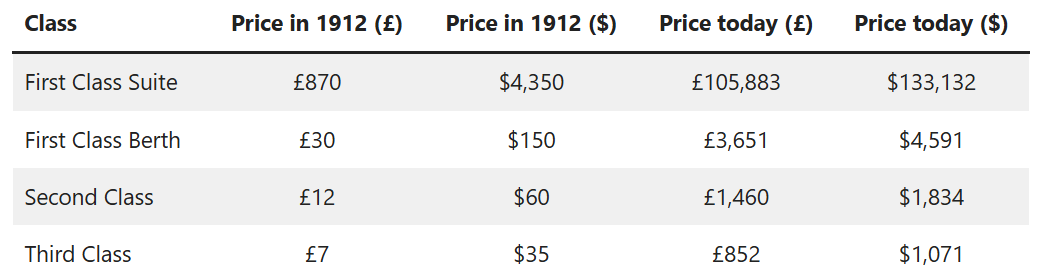


Después de haber lidiado con este problema, el siguiente paso es identificar los valores faltantes. Para esto, se encuentran las casillas vacías con la función `.isnull`, para después hacer una suma de estos valores, con la función `.sum()`. Esto se hace para los datos de `X`tanto de train como de test. De igual manera se hace este mismo procedimiento para la `y`, aunque no debería encontrarse ninguno.









In [5]:
print("\nMissing values in X_train:")
display(X_train.isnull().sum())

print("\nMissing values in X_test:")
display(X_test.isnull().sum())

print("\nMissing values in y_train (should be 0):")
display(y_train.isnull().sum())

print("\nMissing values in y_test (should be 0):")
display(y_test.isnull().sum())


Missing values in X_train:


,0
Pclass,0
Sex,0
Age,137
SibSp,0
Parch,0
Fare,0
Embarked,2



Missing values in X_test:


,0
Pclass,0
Sex,0
Age,40
SibSp,0
Parch,0
Fare,0
Embarked,0



Missing values in y_train (should be 0):


np.int64(0)


Missing values in y_test (should be 0):


np.int64(0)



Sí se encontraron valores faltantes, por lo que a continuación se comenta cómo se manejan para cada variable.


* **Age**: Esta variable fue la que más valores faltantes. 137 en train y 40 en test. Para arreglar esto, se hará una imputación con la edad mediana, siendo esta menos sensible a outliers. Para esto, se obtiene la mediana de los datos de entrenamiento con `.median()`, para después sustituirlos en los valores faltantes con `.fillna()`. Esta misma mediana se usará para sustituir los huecos en el conjunto de datos de `test`, para que no haya fuga de datos.
* **Embarked**: Para esta columna, como es categórica y son pocos faltantes, se imputarán los datos con la moda. Esto se logra calculando la moda con `mode()` de los datos de entrenamiento. Posteriormente, rellenan los huecos con estos valores en ambos conjuntos de datos.
* **Fare**: Para esta variable, se imputarán los valores faltantes tomando como referencia la mediana de precio por cada clase, ya que estas dos variables están proporcionalmente relacionadas. Para esto se crea una variable `median_fare_per_class` donde se clasifican los datos por tipo de clase (1, 2, 3) y se calcula la mediana de los precios, sólo del conjunto de entrenamiento. Luego se reemplazan los datos de acuerdo a la clase, para ambos conjuntos.





In [6]:
# Impute missing 'Age' values with the median from the training set
median_age = X_train['Age'].median()
X_train['Age'].fillna(median_age, inplace=True)
X_test['Age'].fillna(median_age, inplace=True)

# Impute missing 'Embarked' values with the mode from the training set
mode_embarked = X_train['Embarked'].mode()[0]
X_train['Embarked'].fillna(mode_embarked, inplace=True)
X_test['Embarked'].fillna(mode_embarked, inplace=True)

# Impute missing 'Fare' values based on 'Pclass' from the training set
# Calculate median fare per Pclass from X_train
median_fare_per_pclass = X_train.groupby('Pclass')['Fare'].median()

# Fill missing values in X_train using the calculated medians
X_train['Fare'] = X_train.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(median_fare_per_pclass[x.name]))

# Fill missing values in X_test using the calculated medians from X_train
# We need to iterate through Pclass in X_test and apply the corresponding median from X_train
for pclass in median_fare_per_pclass.index:
    X_test.loc[(X_test['Pclass'] == pclass) & (X_test['Fare'].isnull()), 'Fare'] = median_fare_per_pclass[pclass]

print("\nMissing values after imputation in X_train:")
display(X_train.isnull().sum())

print("\nMissing values after imputation in X_test:")
display(X_test.isnull().sum())


Missing values after imputation in X_train:


/tmp/ipython-input-172/2059508755.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train['Age'].fillna(median_age, inplace=True)
/tmp/ipython-input-172/2059508755.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0



Missing values after imputation in X_test:


,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


Como se puede observar, ya no se encontraron valores vacíos en los conjuntos de datos.
Ahora, se debe lidiar con las variables categóricas, como lo son `Embarked` y `Sex`, ya que no se puede realizar un modelo con esto. Para solucionar este problema, se usará one-hot encoding. Este proceso convierte variables categóricas a un formato numérico, creando nuevas columnas binarias para cada categoría. Se inicia este proceso creando **dummies**, con la función `get_dummies`, usando los datos de ambos conjuntos y las columnas con las variables de interés. Para confirmar, se imprimen las primeras filas de ambos conjuntos con las variables transformadas.





In [7]:
X_train = pd.get_dummies(X_train, columns=['Sex', 'Embarked'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Sex', 'Embarked'], drop_first=True)

print("\nFirst 5 rows of X_train after one-hot encoding:")
display(X_train.head())

print("\nFirst 5 rows of X_test after one-hot encoding:")
display(X_test.head())


First 5 rows of X_train after one-hot encoding:


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
692,3,28.5,0,0,56.4958,True,False,True
481,2,28.5,0,0,0.0000,True,False,True
527,1,28.5,0,0,221.7792,True,False,True
855,3,18.0,0,1,9.3500,False,False,True
801,2,31.0,1,1,26.2500,False,False,True



First 5 rows of X_test after one-hot encoding:


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
565,3,24.0,2,0,24.1500,True,False,True
160,3,44.0,0,1,16.1000,True,False,True
553,3,22.0,0,0,7.2250,True,False,False
860,3,41.0,2,0,14.1083,True,False,True
241,3,28.5,1,0,15.5000,False,True,False


Para asegurar que todas las variables aporten lo mismo al modelo y éste no se vea afectado más por variables con rangos muy altos, como `Fare`, se decide hacer una estandarización de las variables numéricas, dejando fuera las variables binarias para mantener la interpretabilidad de estas últimas. Este proceso se trata de hacer la media 0 y la desviación estándar 1. Se importa la librería `StandarScaler`, para después crear el objeto `scaler`. Después se identifican las variables numéricas que se van a escalar (`numerical_cols_to_scale`) y las variables binarias (`binary_cols`)
Después se guarda en la variable `x_train_scaled_numerical`, donde `fit()` calcula la media y desviación estándar de las variables de entrenamiento. Posteriormente se usa `transform()` que aplica la fórmula de estandarización. Luego se estandarizan los valores de la sección de prueba, usando la escala obtenida con los datos de entrenamiento. Esto se hace para que no haya fuga de datos en el modelo. Es por eso que en la variable `x_test_scaled`se usa sólo la función `transform`, sin la función `fit`.


Al estandarizar, se devuelven los valores en arrays, por no que las columnas no tienen nombre. Para poder tener más calidad manejando las variables, se convierte este resultado a DataFrame, volviendo a incluir los nombres de las columnas y luego imprimirlos para asegurar que se haya realizado correctamente.




Esto se logra con la función `DataFrame()`, la cual crea un DataFrame. Dentro de esta función se incluyen los datos a convertir, se añade de dónde se obtendrán las columnas (`columnas = numerical_cols_to_scale`), y que se preserven los índices originales para que no se pierda el orden (`index = X_train.index`). Este mismo proceso se hace para los datos de prueba. Posteriormente se imprimen las primeras cinco filas de ambos conjuntos de datos con `head()`.





In [8]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Initialize StandardScaler
scaler = StandardScaler()

# Identify numerical columns to scale (excluding binary one-hot encoded columns)
numerical_cols_to_scale = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
binary_cols = ['Sex_male', 'Embarked_Q', 'Embarked_S']

# Apply scaling to numerical columns in X_train and X_test
X_train_scaled_numerical = scaler.fit_transform(X_train[numerical_cols_to_scale])
X_test_scaled_numerical = scaler.transform(X_test[numerical_cols_to_scale])

# Convert scaled numerical arrays back to DataFrames
X_train_scaled_numerical_df = pd.DataFrame(X_train_scaled_numerical, columns=numerical_cols_to_scale, index=X_train.index)
X_test_scaled_numerical_df = pd.DataFrame(X_test_scaled_numerical, columns=numerical_cols_to_scale, index=X_test.index)

# Combine scaled numerical columns with unscaled binary columns
X_train_scaled = pd.concat([X_train_scaled_numerical_df, X_train[binary_cols]], axis=1)
X_test_scaled = pd.concat([X_test_scaled_numerical_df, X_test[binary_cols]], axis=1)

print("\nFirst 5 rows of X_train after feature scaling (numerical columns only scaled):")
display(X_train_scaled.head())

print("\nFirst 5 rows of X_test after feature scaling (numerical columns only scaled):")
display(X_test_scaled.head())


First 5 rows of X_train after feature scaling (numerical columns only scaled):


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
692,0.829568,-0.081135,-0.465084,-0.466183,0.513812,True,False,True
481,-0.370945,-0.081135,-0.465084,-0.466183,-0.662563,True,False,True
527,-1.571457,-0.081135,-0.465084,-0.466183,3.955399,True,False,True
855,0.829568,-0.887827,-0.465084,0.727782,-0.467874,False,False,True
801,-0.370945,0.110934,0.478335,0.727782,-0.115977,False,False,True



First 5 rows of X_test after feature scaling (numerical columns only scaled):


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
565,0.829568,-0.426860,1.421753,-0.466183,-0.159704,True,False,True
160,0.829568,1.109696,-0.465084,0.727782,-0.327324,True,False,True
553,0.829568,-0.580516,-0.465084,-0.466183,-0.512122,True,False,False
860,0.829568,0.879212,1.421753,-0.466183,-0.368795,True,False,True
241,0.829568,-0.081135,0.478335,-0.466183,-0.339817,False,True,False


Se puede observar que ahora los valores de las variables no tienen un rango tan amplio como antes.


Una vez resueltos los problemas, se puede pasar a hacer el modelo. Para comenzar, se importan las librerías `LogosticRegression` (para crear el modelo), `StratifiedKFold` (para hacer la validación cruzada manteniendo las mismas cantidades de clases), y `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `classification_report`(para las métricas).


Después se crea un modelo de regresión logística, optimizando la regresión logística con `solver='liblinear'` para una base de datos pequeños, usando una semilla de aleatoriedad para siempre obtener la misma división y mismos resultados, y añadiendo `max_inter=200` como máxima cantidad de iteraciones.  
Después de define la validación cruzada con `StratifiedKFold()` añadiendo los parámetros `n_split=4` (dividir los datos de entrenamiento en 5 partes. Cada iteración tendrá 4 *folds* de entrenamiento y 1 de validación), `suffle=True` (para mezclar los datos antes de dividirlos y poder obtener resultados diferentes y valiosos en cada iteración), `random_state=42` y `Stratified`(para mantener la porción de clases en cada división).  
Posteriormente se crean las lista para guardar las métricas con las que se evaluará el modelo por cada *fold*. Después se calculará el promedio.  
Se continúa con la creación de un loop para la validación cruzada. Con la función `skf.split(X_train_scaled, y_train)` se devuelven índices para entrenar e índices para validar. En cada iteración se cambian los datos que se usan para validar. (GeeksforGeeks, 2025)  
Después se separar los datos en cada *fold*, con datos para entrenar ese *fold* y datos para validarlo. Con `model.fit()` se entrena el modelo; aprende los coeficientes y ajusta la regresión logística. Esto se hace con cada *fold*. Luego se hacen las predicciones, usando la función `model.predict()` con los datos de validación que se asignaron para cada *fold*. Para evaluar su exactitud, se usa la función `accuracy_score()` ingresando los valores de `y` reales y las predicciones para esta variable (`Survived`).


Luego se calculan las métricas para cada uno de los folds; accuracy (exactitud), precision (precisión), recall (sensibilidad), f1 score.
* $Accuracy = \frac{Prediccionescorrectas}{totalobservaciones}$ -> Proporción de las predicciones que fueron correctas.


* $Precision = \frac{TP}{TP+FP}$ -> Proporción de los "*Verdaderos Positivos (TP)* de todas las predicciones que fueron marcadas como positivas.


* $Recall = \frac{TP}{TP + FN}$ -> Proporción de los "*Verdaderos Positivos (TP)*" frente a todo lo que sí era positivo.


* $F1 = 2 * \frac{Precision * Recall}{Precision + Recall}$ -> Promedio armónico.


Estas métricas se calculan con las funciones `accuracy_score()`, `precision_score()`, `recall_score()` y `f1_score()`, que toman como parámetros los valores reales de `y` y los valores predichos de esta variable.
Se guardan en una lista para poder calcular las estadísticas finales, con `append()`. Por último se imprimen los promedios finales de cada métrica, al igual que la desviación estándar, con las funciones `np.mean()` y `np.std()` respectivamente.


La validación cruzada permite evaluar el modelo múltiples veces con diferentes "particiones" del mismo conjunto de entrenamiento, cosa que no se puede hacer si sólo se entrena con una sola partición. Y, al hacerla estratificada, se puede asegurar que el modelo no sólo entrene con un tipo de clase. Para este ejemplo, hay un desbalance en los datos, teniendo más pasajeros que no sobrevivieron. Utilizando este método, se puede evitar que el modelo sólo aprenda que todos murieron y no sea útil para futuros análisis.









In [9]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Initialize Stratified K-Fold Cross-Validation
n_splits = 5  # Number of folds
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Initialize lists to store metrics for each fold
fold_accuracies = []
fold_precisions = []
fold_recalls = []
fold_f1_scores = []

# Perform Stratified K-Fold Cross-Validation
print(f"Performing {n_splits}-Fold Stratified Cross-Validation...")
for fold, (train_index, val_index) in enumerate(skf.split(X_train_scaled, y_train)): # Use X_train_scaled for CV
    X_train_fold, X_val_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Initialize and train the Logistic Regression model
    log_reg_fold = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets
    log_reg_fold.fit(X_train_fold, y_train_fold)

    # Make predictions on the validation set
    y_pred_fold = log_reg_fold.predict(X_val_fold)

    # Calculate metrics for the current fold
    fold_accuracies.append(accuracy_score(y_val_fold, y_pred_fold))
    fold_precisions.append(precision_score(y_val_fold, y_pred_fold))
    fold_recalls.append(recall_score(y_val_fold, y_pred_fold))
    fold_f1_scores.append(f1_score(y_val_fold, y_pred_fold))

    print(f"Fold {fold + 1} - Accuracy: {fold_accuracies[-1]:.4f}, Precision: {fold_precisions[-1]:.4f}, Recall: {fold_recalls[-1]:.4f}, F1-Score: {fold_f1_scores[-1]:.4f}")

# Calculate and print average metrics across all folds
print(f"\nAverage Metrics Across {n_splits} Folds:")
print(f"Mean Accuracy: {np.mean(fold_accuracies):.4f} (+/- {np.std(fold_accuracies):.4f})")
print(f"Mean Precision: {np.mean(fold_precisions):.4f} (+/- {np.std(fold_precisions):.4f})")
print(f"Mean Recall: {np.mean(fold_recalls):.4f} (+/- {np.std(fold_recalls):.4f})")
print(f"Mean F1-Score: {np.mean(fold_f1_scores):.4f} (+/- {np.std(fold_f1_scores):.4f})")



Performing 5-Fold Stratified Cross-Validation...
Fold 1 - Accuracy: 0.7972, Precision: 0.7407, Recall: 0.7273, F1-Score: 0.7339
Fold 2 - Accuracy: 0.7972, Precision: 0.7955, Recall: 0.6364, F1-Score: 0.7071
Fold 3 - Accuracy: 0.7958, Precision: 0.7600, Recall: 0.6909, F1-Score: 0.7238
Fold 4 - Accuracy: 0.7465, Precision: 0.6607, Recall: 0.6852, F1-Score: 0.6727
Fold 5 - Accuracy: 0.8310, Precision: 0.8000, Recall: 0.7407, F1-Score: 0.7692

Average Metrics Across 5 Folds:
Mean Accuracy: 0.7935 (+/- 0.0270)
Mean Precision: 0.7514 (+/- 0.0504)
Mean Recall: 0.6961 (+/- 0.0365)
Mean F1-Score: 0.7214 (+/- 0.0317)


De estos datos se puede decir que el rendimiento es bastante consistente entre los *folds*, siendo el *fold* 5 el mejor y el *fold* 4 el peor. Debido a que no hay variaciones extremas, se podría decir que el modelo es bastante estable. El modelo, en promedio, clasifica correctamente al 79.35% de los pasajeros, con una desviación estándar del 2.7%, relativamente baja. Por otro lado, cuando el modelo predice que alguien sobrevivió está correcto el 75.1% de las veces, con una variación del 5%. Aunque esta variación no es tan alta, sí muestra un poco de inestabilidad en falsos positivos. Por el contrario, de los pasajeros que realmente sobrevivieron, el modelo sólo fue capaz de detectar el 69.6%, un valor bajo ya que pierde casi el 30% de las personas que sobrevivieron.









---


Ahora, se entrenará un modelo de regresión logística usando todo el conjunto de datos de entrenamiento y posteriormente se evaluará el desempeño en los datos de prueba. Para esto, se vuelve a crear un modelo logístico, guardándolo en la variable `final_log_reg_model`, ingresando los datos de `X_train_scaled` y `y_train`. Después, se hacen las predicciones usando este modelo, ingresando los datos de `X` escalados de prueba. Después se calcula la probabilidad de pertenecer a cada clase, para todas las filas.  
Después, se imprime la matriz de confusión, usando la función `confusion_matrix`, con los valores reales de `y`de prueba y los valores predichos para `y` para el conjunto de prueba. El umbral usado para esto está en 0.5. Se usa la función de `confusionMatrixDisplay` para tener una mejor visualización de este indicador. Posteriormente, se imprime el reporte del desempeño del modelo, con los datos de prueba.


Después de esto, se cambia el umbral, de 0.5 a 0.90. El modelo sólo predecirá que alguien sobrevivirá si está 90% seguro de que es el caso, para no dar falsas esperanzas a las personas de qué se espera en una catástrofe marítima de acuerdo a las variables analizadas. Se hacen los mismos cálculos y se imprime la nueva matriz de confusión, al igual que las métricas para evaluar al modelo.  








--- Model Performance on Test Set (Default Threshold 0.5) ---

Confusion Matrix:


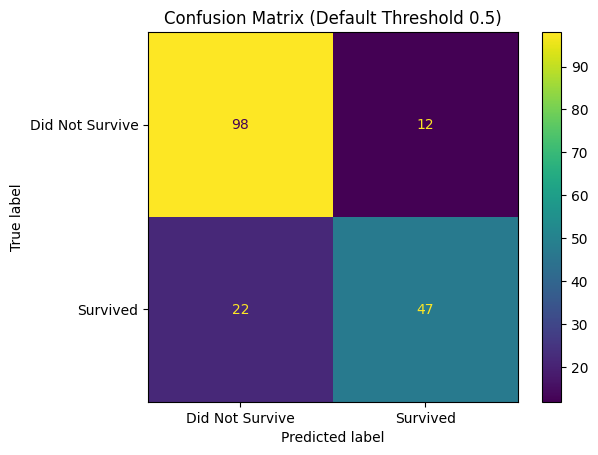


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       110
           1       0.80      0.68      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179


--- Model Performance on Test Set (Custom Threshold 0.9) ---

Confusion Matrix (Custom Threshold):


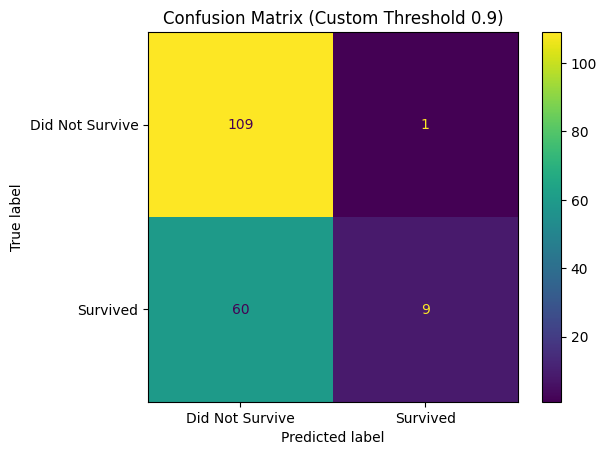


Classification Report (Custom Threshold):
              precision    recall  f1-score   support

           0       0.64      0.99      0.78       110
           1       0.90      0.13      0.23        69

    accuracy                           0.66       179
   macro avg       0.77      0.56      0.50       179
weighted avg       0.74      0.66      0.57       179



In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Initialize and train the Logistic Regression model on the full training set
final_log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
final_log_reg_model.fit(X_train_scaled, y_train)

# Make predictions and get probabilities on the scaled test set
y_pred_test = final_log_reg_model.predict(X_test_scaled)
y_proba_test = final_log_reg_model.predict_proba(X_test_scaled)[:, 1]

# --- Evaluate Model Performance on Test Set ---
print("\n--- Model Performance on Test Set (Default Threshold 0.5) ---")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)
print("\nConfusion Matrix:")
# display(conf_matrix)
# Plot confusion matrix for better visualization
cmd_default = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, display_labels=['Did Not Survive', 'Survived'])
plt.title('Confusion Matrix (Default Threshold 0.5)')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))


# --- Evaluate Model Performance with a Different Threshold (e.g., 0.90) ---
custom_threshold = 0.9
y_pred_test_custom_threshold = (y_proba_test >= custom_threshold).astype(int)

print(f"\n--- Model Performance on Test Set (Custom Threshold {custom_threshold}) ---")

# Confusion Matrix with custom threshold
conf_matrix_custom = confusion_matrix(y_test, y_pred_test_custom_threshold)
print("\nConfusion Matrix (Custom Threshold):")
# display(conf_matrix_custom)
# Plot confusion matrix with custom threshold for better visualization
cmd_custom = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test_custom_threshold, display_labels=['Did Not Survive', 'Survived'])
plt.title(f'Confusion Matrix (Custom Threshold {custom_threshold})')
plt.show()

# Classification Report with custom threshold
print("\nClassification Report (Custom Threshold):")
print(classification_report(y_test, y_pred_test_custom_threshold))

Las matrices de confusión muestran lo siguiente:
* Con un umbral de 0.5:
   * 98 predichos como que no sobrevivieron y realmente no sobrevivieron (TN)
   * 22 predichos como que no sobrevivieron pero realmente sí sobrevivieron (FN)
   * 12 predichos como que sí sobrevivieron pero realmente no sobrevivieron (FP)
   * 47 predichos como que sí sobrevivieron y realmente sí sobrevivieron (TP)


* Con un umbral de 0.9:
   * 109 predichos como que no sobrevivieron y realmente no sobrevivieron (TN)
   * 60 predichos como que no sobrevivieron pero realmente sí sobrevivieron (FN)
   * 1 predichos como que sí sobrevivieron pero realmente no sobrevivieron (FP)
   * 9 predichos como que sí sobrevivieron y realmente sí sobrevivieron (TP)


Se puede ver cómo con un umbral más conservador sólo hubo una persona que no sobrevivió que fue clasificada como que sí sobrevivió. Para el fin que se había estipulado antes, de no dar falsas esperanzas, esto podría parecer algo muy bueno. Sin embargo, 60 personas que sí sobrevivieron no fueron detectadas por el modelo, marcándolas como fatalidad. Estas limitaciones del modelo también se ven reflejadas en las métricas calculadas.


**Comparación de métricas entre umbral de 0.5 y 0.9, respectivamente, para la clase 1 (sí sobrevivió):**


* Precisión: 0.80 y 0.90. Esto demuestra que el modelo con el umbral de 0.9 pocas veces se equivoca cuando dice que alguien sobrevivió, como se vio en la matriz de confusión.
* Sensibilidad: 0.68 y 0.13. Esto indica que con el nuevo umbral, sólo se detectan el 13% de los sobrevivientes reales. El modelo se volvió demasiado conservador a la hora de decir si la persona va a sobrevivir o no.
* Exactitud: 0.81 y 0.66. Este valor cayó mucho. El nuevo umbral clasificó a casi todos como fatalidad, clasificando erróneamente a personas que sí sobrevivieron. Matemáticamente, el modelo está muy desequilibrado.


---


Para continuar, se hará la curva ROC para visualizar el desempeño del modelo en diferentes umbrales. La curva gráfica la tasa de Verdaderos positivos (Sensibilidad) contra la tasa de Falsos Positivos (1 - especificidad). También se calculará el área bajo la curva (AUC) con la intención de ver el desempeño del modelo.


Para hacer esto, se importa la librería `roc_curve` y `roc_auc_score`, para poder usar sus funciones que permitan estos cálculos. También se importa la librería `matplotlib.pyplot` para poder graficar esta curva y usar todas las funciones necesarias para esto. Después se calculan la tasa de Falsos Positivos (`fpr`), la tasa de Verdaderos Positivos (`tpr`) y todos los posibles umbrales (`threshold`). Posteriormente se pasa a graficar la curva con `plt.figure`, agregando límites de 0 a 1 para ambos ejes, añadiendo nombres a los ejes; `False Positive Rate` para el eje `x` y `True PositiveRate` para el eje `y`. Se muestra la gráfica con `plt.show()`. Además, para mejor visualización, se le agrega una cuadrícula con `plt.grid(True)`.





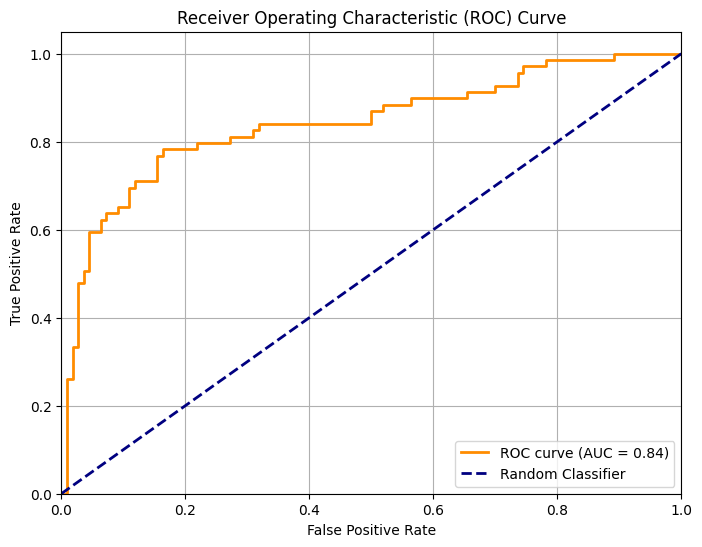


ROC AUC Score: 0.8430


In [11]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_test)

# Calculate AUC score
roc_auc = roc_auc_score(y_test, y_proba_test)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"\nROC AUC Score: {roc_auc:.4f}")

Con un área bajo la curva de 0.84, se puede decir que la probabilidad de que el modelo asigna una mayor probabilidad de supervivencia a un pasajero que sí sobrevivió que a uno que no es de 0.84. Esto indica que el modelo tiene buena capacidad discriminatoria y puede distinguir bien entre ambas clases.


Con respecto a la curva, se puede decir que está por encima de la diagonal, que indica un clasificador aleatorio. Una curva de esta forma muestra que el modelo puede alcanzar altos valores de sensibilidad con tasas relativamente bajas de falsos positivos.





---
Finalmente, se obtienen los coeficientes de cada variable para ver cómo estas contribuyen al modelo. Se guardan los coeficientes en una variable `coefficients` obtenidos del modelo final de regresión logística, con la función `coef_[0]`. También se guardan los nombres de las columnas en `features_names`, usando la función `.columns`. Después se crea un DataFrame para poder imprimir estos valores. Por último, se ordenan por orden de influencia (de mayor a menor) sin importar si la relación es positiva o negativa. Esto se hace obteniendo el valor absoluto con `abs()` y ordenándolos con `sort_values`.







In [12]:

# Get coefficients and feature names from the trained model
coefficients = final_log_reg_model.coef_[0]
feature_names = X_train_scaled.columns

# Create a DataFrame to display coefficients
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute value of coefficient to see most influential features
coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).drop(columns='Abs_Coefficient')

print("\nLogistic Regression Model Coefficients (sorted by absolute value):")
display(coef_df)


Logistic Regression Model Coefficients (sorted by absolute value):


,Feature,Coefficient
5,Sex_male,-2.528769
0,Pclass,-0.917257
1,Age,-0.501511
6,Embarked_Q,0.348117
7,Embarked_S,-0.328726
2,SibSp,-0.258158
4,Fare,0.105935
3,Parch,-0.055677


Como se puede observar, la mayor influencia en los momios de si sobrevivir o morir es el sexo. Como es bien sabido, se tiene a dar preferencia a mujeres y niños para abordar los botes salvavidas; esto podría explicar porqué el ser hombre tiene como consecuencia un decremento de -2.53 en el logaritmo natural de los momios de sobrevivir en comparación a que si fuera una mujer. La siguiente variable que afecta mucho es la clase del pasajero, pertenecer a una clase más alta en número (siendo la tercera más alta, no hablando de privilegio), decrementa -0.92 el logaritmo natural d los momis de sobrevivir. La variable `Age` también tiene una relación negativ (-0.05); entre mayor la edad, mayor será el decremento en el logaritmo de los momios de sobrevivir. Sin embargo, es importante mencionar que esta variable tenía muchos datos faltantes y fueron imputados, por lo que el modelo pudo haber sido influenciado. Haber embarcado en Queenstown tiene un efecto positivo, indicando un ligero aumento en el logaritmo natural de sobrevivir (0.35), mientras que haber embarcado en Southampton decrementa ligeramente el logaritmo natural de los momios de sobrevivir (-0.33). No se encontró una posible explicación de porqué embarcar en un puerto a diferencia de otro podría afectar la probabilidad de vivir. Estos coeficiente representan el impacto de `Embarked_Q` y `Embarked_S`, a diferencia de haber embarcado en el puerto base, Cherbourg. Luego, se tiene la variable `SibSp`, que también tiene un coeficiente negativo, lo cual indica que por cada hermano/esposo extra que se tienen a bordo, hay un decremento de -0.26 en el logaritmo natural de los momios de sobrevivir. Continuando, la variable `Fare` muestra un incremento de 0.11 en el logaritmo natural de los momios de sobrevivir por cada libra extra que se pague por el boleto. Esta variable, relacionada a la economía del pasajero, podría estar correlacionada con la variable `Pclass`, debido que entre más se paga por un boleto, normalmente tiende a ser mejor la cabina que se recibe. Normalmente, las personas con mayor estatus socioeconómico suelen tener preferencia a la hora de abordar los botes salvavidas. Por último, se tiene la variable `Parch`, la cuál también tiene una relación negativa, aunque muy pequeña. Por cada padre o hijo del pasajero extra que esté a bordo, se espera que el logaritmo natural del momio de sobrevivir decrementa -0.056. Esta relación negativa, al igual que con la variable `SibSp`, podría deberse a que, como se mencionó anteriormente, se priorice el bienestar de los seres queridos y entre más seres queridos, más gente que priorizar y menos oportunidad de abordar los botes salvavidas.


---


Para concluir, se puede decir que el modelo hace sentido si se toma en cuenta el contexto; prioridad a mujeres y niños, clases socioeconómicas altas, y desventajas para los que tienen familiares que atender y no prioricen su vida. Para futuros trabajos, se debería hacer un análisis de posible colinealidad entre variables y considerar interacción entre ellas. Aunque en la actualidad hay más medidas de seguridad en los múltiples medios de transporte y se procura salvaguardar la vida de todos los pasajeros, sin discriminar, aún siguen existiendo este tipo de disparidades cuando se trata de supervivencia, especialmente en países en vías de desarrollo o en grupos minoritarios.



**Referencias**

* Colaboradores de Wikipedia. (n.d.). Anexo:Pasajeros a bordo del RMS Titanic - Wikipedia, la enciclopedia libre. https://es.wikipedia.org/wiki/Anexo:Pasajeros_a_bordo_del_RMS_Titanic
* Titanic Dataset. (2021, December 24). https://www.kaggle.com/datasets/yasserh/titanic-dataset
* Fielding, J. (2025, October 18). How much was a ticket on the Titanic (and how does it compare to cruise fares today)? Cruise Mummy. https://www.cruisemummy.co.uk/titanic-ticket-prices/
* What-are-the-advantages-and-disadvantages-of-quartile-in-statics
* GeeksforGeeks. (2025, July 15). Stratified K Fold Cross Validation. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/stratified-k-fold-cross-validation/


**Código de Honor**: Doy mi palabra que he realizado esta actividad con integridad académica.  

Se implementó el uso de IA unicamente para dudas de redacción y código.


